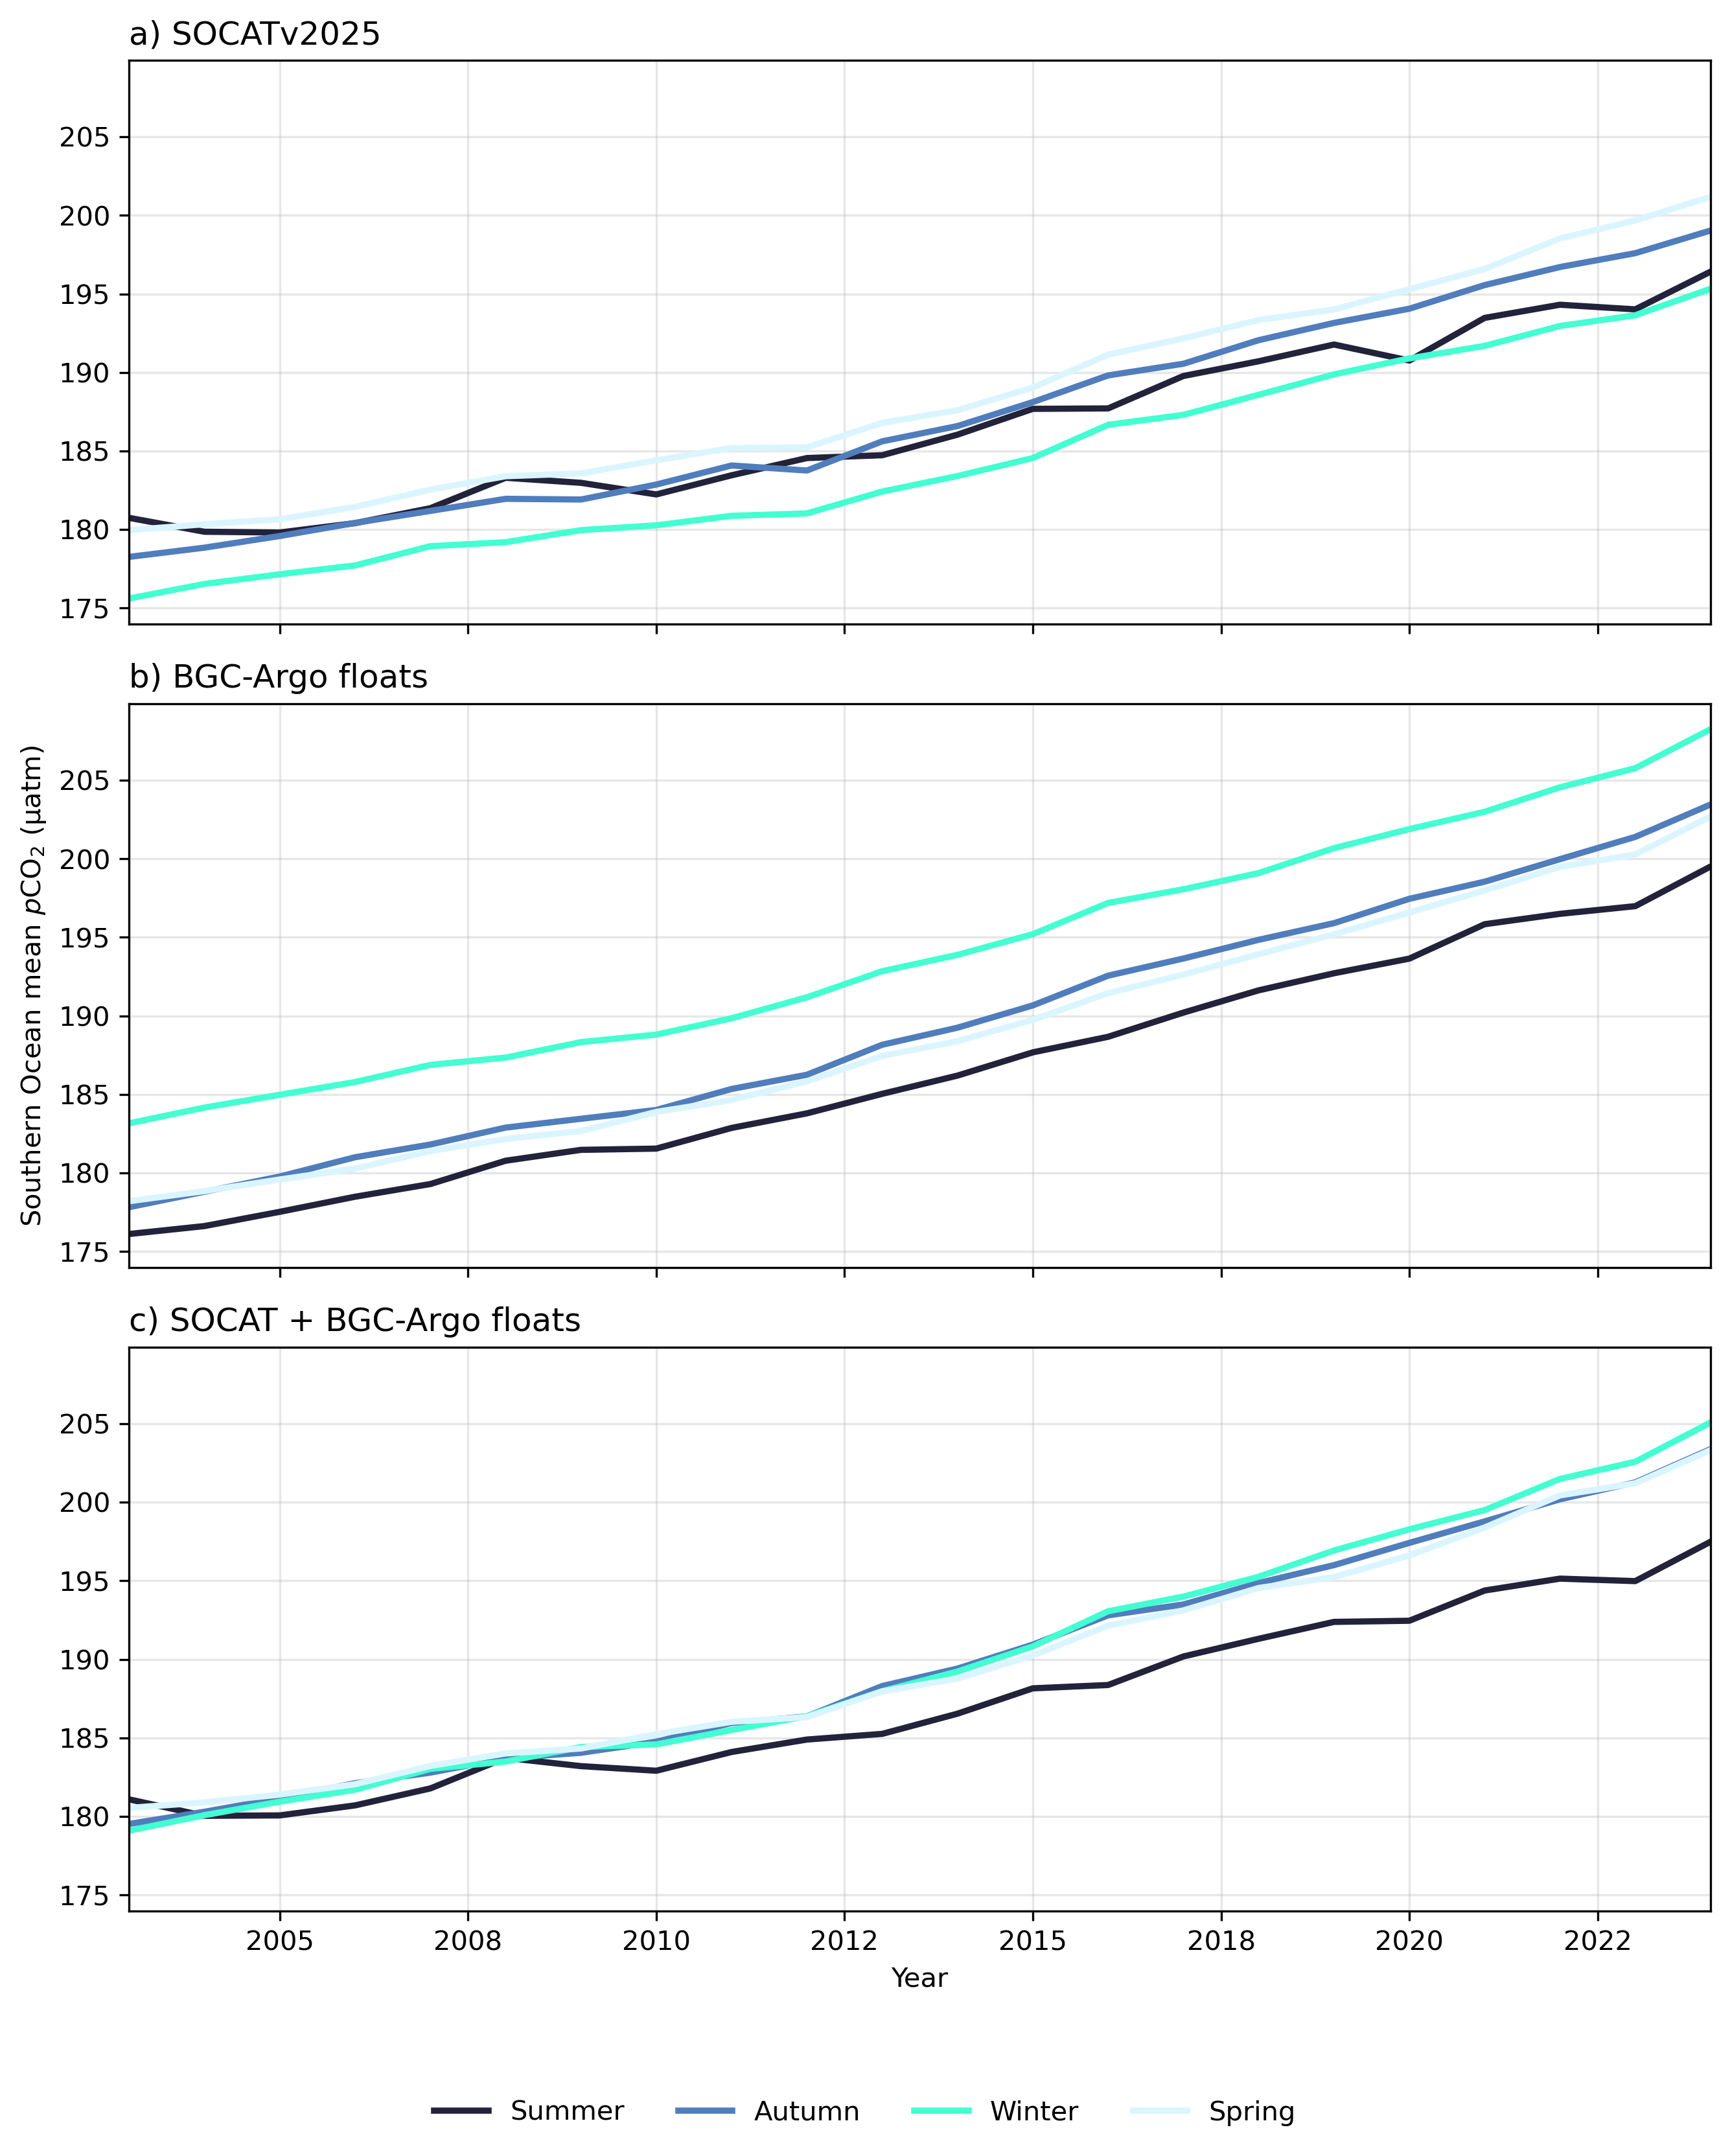

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# -----------------------------
# Paths
# -----------------------------
paths = {
    "SOCATv2025": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_SOCAT_only_MCensemble.csv",
    "BGC-Argo floats": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_FLOATS_only_MCensemble.csv",
    "SOCAT + BGC-Argo floats": "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/PREDICTION_MATRIX_v2/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_weighted_MCensemble.csv",
}

# -----------------------------
# Helpers
# -----------------------------
def _find_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _infer_time_columns(df):
    dt_col = _find_first_col(df, ["time", "date", "datetime", "Timestamp", "timestamp"])
    if dt_col is not None:
        dt = pd.to_datetime(df[dt_col])
        return dt, dt.dt.month.astype(int)

    y_col = _find_first_col(df, ["year", "Year", "YEAR"])
    m_col = _find_first_col(df, ["month", "Month", "MONTH"])
    if y_col is not None and m_col is not None:
        y = df[y_col].astype(int)
        m = df[m_col].astype(int)
        dt = pd.to_datetime(dict(year=y, month=m, day=1))
        return dt, m

    ym_col = _find_first_col(df, ["yyyymm", "YYYYMM", "yearmonth"])
    if ym_col is not None:
        s = df[ym_col].astype(str)
        dt = pd.to_datetime(s, format="%Y%m")
        return dt, dt.dt.month.astype(int)

    raise ValueError("No recognizable time columns found.")


def _infer_lat_lon_columns(df):
    lat_col = _find_first_col(df, ["lat", "LAT", "latitude", "Latitude"])
    lon_col = _find_first_col(df, ["lon", "LON", "longitude", "Longitude"])
    return lat_col, lon_col


def _infer_pco2_columns(df):
    preferred = [c for c in df.columns if "ensemble_pco2" in c.lower()]
    preferred = [c for c in preferred if pd.api.types.is_numeric_dtype(df[c])]
    if preferred:
        return preferred

    pco2_like = [c for c in df.columns if "pco2" in c.lower()]
    pco2_like = [c for c in pco2_like if pd.api.types.is_numeric_dtype(df[c])]
    if pco2_like:
        return pco2_like

    exclude = [
        "lat", "LAT", "latitude", "Latitude",
        "lon", "LON", "longitude", "Longitude",
        "year", "Year", "YEAR",
        "month", "Month", "MONTH",
        "time", "date", "datetime", "Timestamp", "timestamp",
    ]

    numeric_cols = [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c]) and c not in exclude
    ]

    if not numeric_cols:
        raise ValueError("No pCO2 columns found.")

    return numeric_cols


def month_to_season_sh(m: int) -> str:
    if m in (12, 1, 2):
        return "Summer"
    if m in (3, 4, 5):
        return "Autumn"
    if m in (6, 7, 8):
        return "Winter"
    return "Spring"


def seasonal_timeseries_strict_season_year(csv_path: str) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by season_year with columns
    [Summer, Autumn, Winter, Spring], where:
    DJF(YYYY) = Dec(YYYY-1) + Jan(YYYY) + Feb(YYYY)
    """
    df = pd.read_csv(csv_path)

    dt, _ = _infer_time_columns(df)
    df = df.copy()
    df["_dt"] = pd.to_datetime(dt)
    df["_year"] = df["_dt"].dt.year.astype(int)
    df["_month"] = df["_dt"].dt.month.astype(int)

    lat_col, lon_col = _infer_lat_lon_columns(df)
    pco2_cols = _infer_pco2_columns(df)

    df["_pco2_rowmean"] = df[pco2_cols].mean(axis=1, skipna=True)

    group_cols = ["_dt"]
    if lat_col is not None:
        group_cols.append(lat_col)
    if lon_col is not None:
        group_cols.append(lon_col)

    cell_month = df.groupby(group_cols, as_index=False)["_pco2_rowmean"].mean()

    monthly = cell_month.groupby("_dt", as_index=False)["_pco2_rowmean"].mean()
    monthly = monthly.rename(columns={"_pco2_rowmean": "pco2_basin"})
    monthly["_year"] = pd.to_datetime(monthly["_dt"]).dt.year.astype(int)
    monthly["_month"] = pd.to_datetime(monthly["_dt"]).dt.month.astype(int)

    monthly = monthly[~((monthly["_year"] == 2023) & (monthly["_month"] == 2))].copy()

    monthly["season"] = monthly["_month"].map(month_to_season_sh)
    monthly["season_year"] = monthly["_year"]
    monthly.loc[monthly["_month"] == 12, "season_year"] += 1

    seasonal = (
        monthly.groupby(["season_year", "season"], as_index=False)["pco2_basin"]
        .mean()
        .pivot(index="season_year", columns="season", values="pco2_basin")
        .sort_index()
    )

    desired_order = ["Summer", "Autumn", "Winter", "Spring"]
    existing = [c for c in desired_order if c in seasonal.columns]
    seasonal = seasonal[existing]

    return seasonal


# -----------------------------
# Plot settings
# -----------------------------
season_colors = {
    "Summer": "#22223b",
    "Autumn": "#507dbc",
    "Winter": "#43ffd2",
    "Spring": "#daf5ff",
}

panel_paths = {
    "a) SOCATv2025": paths["SOCATv2025"],
    "b) BGC-Argo floats": paths["BGC-Argo floats"],
    "c) SOCAT + BGC-Argo floats": paths["SOCAT + BGC-Argo floats"],
}

plot_order = ["Summer", "Autumn", "Winter", "Spring"]

# -----------------------------
# Build 3-panel figure
# -----------------------------
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(9, 11),
    dpi=300,
    sharex=True,
    sharey=True,
)

for ax, (title, csv_path) in zip(axes, panel_paths.items()):
    seasonal = seasonal_timeseries_strict_season_year(csv_path)

    for s in plot_order:
        if s in seasonal.columns:
            ax.plot(
                seasonal.index,
                seasonal[s],
                lw=2.3,
                label=s,
                color=season_colors[s],
            )

    ax.set_title(title, loc="left")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.set_xlim(2003, 2024)

axes[-1].set_xlabel("Year")
axes[1].set_ylabel(r"Southern Ocean mean $\it{p}$CO$_2$ (µatm)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/figs/Supp_figure_seasonal_timeseries_3panels_strict_season_year.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()